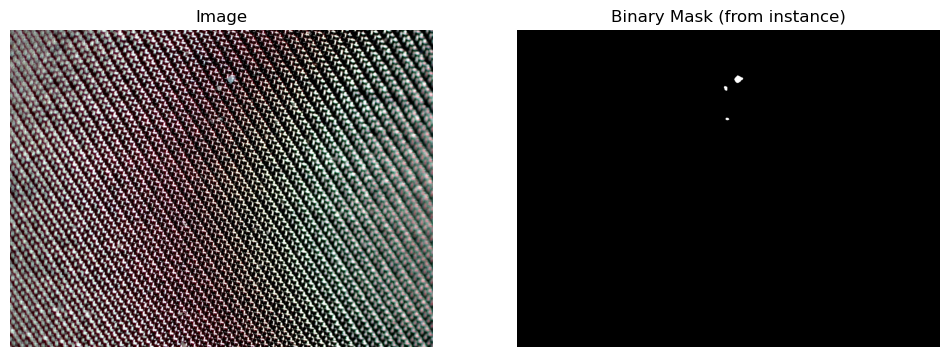

Image shape: (1944, 2592, 3)
Mask shape: (1944, 2592)
Mask values: [0. 1.]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# --- Dataset root ---
ROOT = Path("./data")

# --- Instance segmentation directories ---
IMG_DIR = ROOT / "0_train"
INST_DIR = ROOT / "0_train_instance"

# --- Pick first image ---
img_path = sorted(IMG_DIR.glob("*.jpg"))[0]
mask_path = INST_DIR / (img_path.stem + ".npz")  # instance mask stored as npz

# --- Load image ---
image = np.array(Image.open(img_path))

# --- Load instance mask ---
mask_data = np.load(mask_path)['data']

# --- Extract channel 0 (microplastic presence) ---
mask = mask_data[:,:,0]

# --- Convert to binary: 0 → background, 255 → object ---
mask = (mask == 255).astype(np.float32)

# --- Visualize ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask (from instance)")
plt.axis("off")

plt.show()

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

In [ ]:
#!pip install torch
#!pip install torchvision

# Dataset Creation

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from PIL import Image

# --- Dataset root ---
ROOT = Path("./data")

# --- Train/Valid/Test directories ---
IMG_DIR_TRAIN = ROOT / "0_train"
MASK_DIR_TRAIN = ROOT / "0_train_instance"

IMG_DIR_VALID = ROOT / "1_valid"
MASK_DIR_VALID = ROOT / "1_valid_instance"

IMG_DIR_TEST = ROOT / "2_test"
MASK_DIR_TEST = ROOT / "2_test_instance"

In [2]:
import random

PATCH_SIZE = 256

class MicroplasticBinaryDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=256):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.img_paths = sorted(list(self.img_dir.glob("*.jpg")))
        self.patch_size = patch_size

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img_path = self.img_paths[idx]

        # --- Load image ---
        image = np.array(Image.open(img_path).convert("RGB"))

        # --- Load mask ---
        mask_path = self.mask_dir / (img_path.stem + ".npz")
        mask_data = np.load(mask_path)['data']
        mask = mask_data[:, :, 0]
        mask = (mask == 255).astype(np.float32)

        H, W = image.shape[:2]

        # --- Random patch coordinates ---
        y = random.randint(0, H - self.patch_size)
        x = random.randint(0, W - self.patch_size)

        # --- Crop patch ---
        image = image[y:y+self.patch_size, x:x+self.patch_size]
        mask = mask[y:y+self.patch_size, x:x+self.patch_size]

        # --- Convert to tensor ---
        image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [3]:
# Create dataset instances
train_dataset = MicroplasticBinaryDataset(IMG_DIR_TRAIN, MASK_DIR_TRAIN)
valid_dataset = MicroplasticBinaryDataset(IMG_DIR_VALID, MASK_DIR_VALID)
test_dataset  = MicroplasticBinaryDataset(IMG_DIR_TEST,  MASK_DIR_TEST)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [5]:
images, masks = next(iter(train_loader))
print("Batch image shape:", images.shape)  # [B,3,H,W]
print("Batch mask shape :", masks.shape)   # [B,1,H,W]
print("Mask unique values in batch:", torch.unique(masks))

Batch image shape: torch.Size([1, 3, 256, 256])
Batch mask shape : torch.Size([1, 1, 256, 256])
Mask unique values in batch: tensor([0.])


# Modeling

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Downsampling path
        for feature in features:
            self.downs.append(self.conv_block(in_channels, feature))
            in_channels = feature
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Upsampling path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(self.conv_block(feature*2, feature))

        self.bottleneck = self.conv_block(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)

        return torch.sigmoid(self.final_conv(x))

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels=3, out_channels=1).to(device)
print(model)

UNet(
  (downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stri

In [7]:
import torch.optim as optim
import torch.nn as nn

# --- Loss function ---
# For binary segmentation, BCE (Binary Cross Entropy) is standard
criterion = nn.BCELoss()
# Optional: later can switch to DiceLoss or BCE+Dice for small objects
# --- Optimizer ---
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [11]:
from tqdm import tqdm

# number of epochs (start small to test)
num_epochs = 5

model.train()  # set model to training mode

for epoch in range(num_epochs):
    
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        # move data to device
        images = images.to(device)
        masks = masks.to(device)

        # clear previous gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, masks)

        # backward pass (compute gradients)
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch 1: 100%|███████████████████████████████████████████████████████████████████| 1531/1531 [1:33:55<00:00,  3.68s/it]


Epoch [1/5] Loss: 0.0540


Epoch 2: 100%|███████████████████████████████████████████████████████████████████| 1531/1531 [4:00:39<00:00,  9.43s/it]


Epoch [2/5] Loss: 0.0404


Epoch 3: 100%|███████████████████████████████████████████████████████████████████| 1531/1531 [1:38:09<00:00,  3.85s/it]


Epoch [3/5] Loss: 0.0344


Epoch 4: 100%|███████████████████████████████████████████████████████████████████| 1531/1531 [3:19:19<00:00,  7.81s/it]


Epoch [4/5] Loss: 0.0360


Epoch 5: 100%|███████████████████████████████████████████████████████████████████| 1531/1531 [2:06:20<00:00,  4.95s/it]

Epoch [5/5] Loss: 0.0357


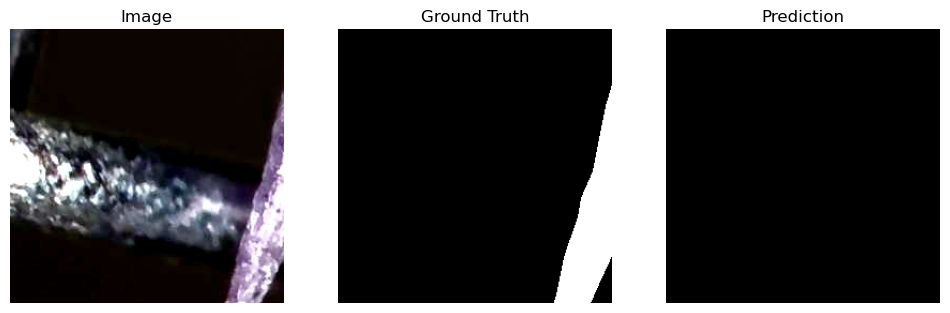

In [15]:
import matplotlib.pyplot as plt

model.eval()

# take one batch
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():   
    preds = model(images)

# move to cpu for visualization
image = images[0].permute(1,2,0).cpu().numpy()
mask = masks[0][0].cpu().numpy()
pred = preds[0][0].cpu().numpy()

# convert probability → binary prediction
pred_binary = (pred > 0.5).astype(float)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")   

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_binary, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

# Plastic-aware patch sampling

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from PIL import Image
import random

# --- Dataset root ---
ROOT = Path("./data")

# --- Train/Valid/Test directories ---
IMG_DIR_TRAIN = ROOT / "0_train"
MASK_DIR_TRAIN = ROOT / "0_train_instance"

IMG_DIR_VALID = ROOT / "1_valid"
MASK_DIR_VALID = ROOT / "1_valid_instance"

IMG_DIR_TEST = ROOT / "2_test"
MASK_DIR_TEST = ROOT / "2_test_instance"


class MicroplasticBinaryDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=256):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.img_paths = sorted(list(self.img_dir.glob("*.jpg")))
        self.patch_size = patch_size

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img_path = self.img_paths[idx]

        # --- Load image ---
        image = np.array(Image.open(img_path).convert("RGB"))

        # --- Load instance mask ---
        mask_path = self.mask_dir / (img_path.stem + ".npz")
        mask_data = np.load(mask_path)['data']
        mask = mask_data[:, :, 0]  # Channel 0
        mask = (mask == 255).astype(np.float32)

        H, W = image.shape[:2]

        # --- Plastic-aware patch sampling ---
        found = False
        for _ in range(10):  # try 10 times
            y = random.randint(0, H - self.patch_size)
            x = random.randint(0, W - self.patch_size)

            img_patch = image[y:y+self.patch_size, x:x+self.patch_size]
            mask_patch = mask[y:y+self.patch_size, x:x+self.patch_size]

            if mask_patch.sum() > 0:
                found = True
                break

        # If no plastic patch found, use last sampled patch
        image = img_patch
        mask = mask_patch

        # --- Convert to tensor ---
        image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


In [17]:
# --- Create datasets ---
train_dataset = MicroplasticBinaryDataset(IMG_DIR_TRAIN, MASK_DIR_TRAIN)
valid_dataset = MicroplasticBinaryDataset(IMG_DIR_VALID, MASK_DIR_VALID)
test_dataset  = MicroplasticBinaryDataset(IMG_DIR_TEST,  MASK_DIR_TEST)


In [18]:
# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [19]:
# --- Test batch ---
images, masks = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch mask shape :", masks.shape)
print("Mask unique values:", torch.unique(masks))

Batch image shape: torch.Size([1, 3, 256, 256])
Batch mask shape : torch.Size([1, 1, 256, 256])
Mask unique values: tensor([0., 1.])


In [ ]:
from tqdm import tqdm

# number of epochs (start small to test)
num_epochs = 5

model.train()  # set model to training mode

for epoch in range(num_epochs):
    
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        # move data to device
        images = images.to(device)
        masks = masks.to(device)

        # clear previous gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, masks)

        # backward pass (compute gradients)
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")
    

Epoch 1:   5%|███▍                                                                 | 75/1531 [04:16<1:25:25,  3.52s/it]